In [1]:
# (1) Latar Belakang
# Perusahaan transportasi taksi memiliki tantangan dalam menjaga produktivitas driver dan kepuasan pelaggan dengan tetap menjaga optimasi pendapatan
# Berdasarkan data operasional, kami melihat adanya fenomena yang perlu ditinjau lebih dalam seperti ditemukannya trip dengan jarak 0, variasi pemasukan per jam, perbedaan demand pada jam tertentu, serta lokasi pickup yang mendominasi permintaan customer
# Analisis ini penting untuk mengoptimalkan productivity driver, meningkatkan efisiensi alokasi armada, generate revenue, serta menjaga loyalitas customer

In [ ]:
# (2) Pernyataan Masalah 
# - Masih ditemukan perjalanan dengan jarak tempuh nol yang terjadi secara berulang. Perlu ditinjau lebih dalam apakah case ini signifikan dan diperlukan monitoring lebih lanjut, mengingat hal tersebut berpotensi dengan fraud, pembatalan, dan operasional yang tidak efisien
# - Jam shift driver yang belum merata. Jam pagi relatif rendah, sementara menumpuk di jam siang hingga sore. Bagaimana melakukan pengaturan shift agar tetap balance dan menghasilkan revenue yang optimal?
# - Terdapat demand tinggi pada zona pickup tertentu, namun distribusi driver masih belum merata. Sehingga perlu dilakukan analisis demand berdasarkan lokasi agar perusahaan dapat melakukan penempatan armada yang tepat sasaran

In [2]:
# (3) Data
# Berikut adalah analisis data yang dilakukan untuk menjawab permasalahan diatas 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import normaltest, chi2_contingency, mannwhitneyu, ttest_ind

In [3]:
# (3.1) Detail dari dataset terdapat 20 kolom, yaitu sebagai berikut : 

# VendorID
# lpep_pickup_datetime
# lpep_dropoff_datetime
# store_and_fwd_flag
# RatecodeID
# PULocationID
# DOLocationID
# passenger_count
# trip_distance	
# fare_amount
# extra
# mta_tax
# tip_amount
# tolls_amount	
# ehail_fee
# improvement_surcharge
# total_amount
# payment_type
# trip_type
# congestion_surcharge

In [4]:
# (3.2) Berikut 5 baris teratas dan terbawah dari dataset NYC TLC Trip Record

df=pd.read_csv(r"C:\Users\T490s\OneDrive\Desktop\PURWADHIKA COURSE\NYC TLC Trip Record.csv")
display(df.head(),df.tail())

C:\Users\T490s\AppData\Local\Temp\ipykernel_6232\2158787208.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r"C:\Users\T490s\OneDrive\Desktop\PURWADHIKA COURSE\NYC TLC Trip Record.csv")


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.9,1.0,0.5,4.03,0.0,NaN,1.0,24.18,1.0,1.0,2.75
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.7,1.0,0.5,2.64,0.0,NaN,1.0,15.84,1.0,1.0,0.00
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.2,1.0,0.5,1.94,0.0,NaN,1.0,11.64,1.0,1.0,0.00
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.5,0.5,1.5,1.70,0.0,NaN,1.0,10.20,1.0,1.0,0.00
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.0,0.5,1.5,0.00,0.0,NaN,1.0,8.00,1.0,1.0,0.00


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
68206,2,2023-01-31 22:29:00,2023-01-31 22:42:00,NaN,NaN,49,62,NaN,4070.82,15.70,0.0,0.0,0.00,0.0,NaN,1.0,16.70,NaN,NaN,NaN
68207,2,2023-01-31 22:40:00,2023-01-31 22:48:00,NaN,NaN,10,205,NaN,2.14,4.41,0.0,0.0,0.00,0.0,NaN,1.0,5.41,NaN,NaN,NaN
68208,2,2023-01-31 23:46:00,2023-02-01 00:02:00,NaN,NaN,66,37,NaN,3.44,16.53,0.0,0.0,3.51,0.0,NaN,1.0,21.04,NaN,NaN,NaN
68209,2,2023-01-31 23:01:00,2023-01-31 23:19:00,NaN,NaN,225,189,NaN,3.03,14.98,0.0,0.0,3.20,0.0,NaN,1.0,19.18,NaN,NaN,NaN
68210,2,2023-01-31 23:51:00,2023-02-01 00:07:00,NaN,NaN,256,140,NaN,5.82,23.65,0.0,0.0,2.00,0.0,NaN,1.0,29.40,NaN,NaN,NaN


In [5]:
# (4) Data Understanding and Cleaning
# (4.1) Berikut adalah informasi kolom dan jenis data dari dataset

print(f'Jumlah baris dan kolom di dataset NYC TLC Trip Record adalah {df.shape}')
df.info()

Jumlah baris dan kolom di dataset NYC TLC Trip Record adalah (68211, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68211 entries, 0 to 68210
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               68211 non-null  int64  
 1   lpep_pickup_datetime   68211 non-null  object 
 2   lpep_dropoff_datetime  68211 non-null  object 
 3   store_and_fwd_flag     63887 non-null  object 
 4   RatecodeID             63887 non-null  float64
 5   PULocationID           68211 non-null  int64  
 6   DOLocationID           68211 non-null  int64  
 7   passenger_count        63887 non-null  float64
 8   trip_distance          68211 non-null  float64
 9   fare_amount            68211 non-null  float64
 10  extra                  68211 non-null  float64
 11  mta_tax                68211 non-null  float64
 12  tip_amount             68211 non-null  float64
 13  tolls_amount           68211 non-

In [6]:
# (4.2) Cek statistik deskriptif dari dataset
# Berdasarkan statistik deskriptif, didapatkan informasi sebagai berikut

display(df.describe(), df.describe(include='object'))

,VendorID,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,68211.000000,63887.000000,68211.000000,68211.000000,63887.000000,68211.000000,68211.000000,68211.000000,68211.000000,68211.000000,68211.000000,0.0,68211.000000,68211.000000,63887.000000,63877.000000,63887.000000
mean,1.863028,1.117160,98.549735,138.429901,1.315870,8.114852,16.603545,0.825431,0.588340,2.139012,0.169627,NaN,0.951625,21.789377,1.373613,1.021933,0.726748
std,0.343820,1.372913,61.244314,76.761311,0.979054,585.105955,13.470121,1.269904,0.385819,3.052710,1.099789,NaN,0.196875,15.457115,0.508039,0.146465,1.212836
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,-70.000000,-2.500000,-0.500000,-10.500000,0.000000,NaN,-1.000000,-71.500000,1.000000,1.000000,-2.750000
25%,2.000000,1.000000,74.000000,74.000000,1.000000,1.110000,9.300000,0.000000,0.500000,0.000000,0.000000,NaN,1.000000,12.900000,1.000000,1.000000,0.000000
50%,2.000000,1.000000,75.000000,138.000000,1.000000,1.850000,13.500000,0.000000,0.500000,1.600000,0.000000,NaN,1.000000,17.900000,1.000000,1.000000,0.000000
75%,2.000000,1.000000,129.000000,219.000000,1.000000,3.210000,19.800000,1.000000,0.500000,3.330000,0.000000,NaN,1.000000,26.150000,2.000000,1.000000,2.750000
max,2.000000,99.000000,265.000000,265.000000,9.000000,120098.840000,490.000000,12.500000,2.750000,222.220000,36.050000,NaN,1.000000,491.000000,5.000000,2.000000,2.750000


,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag
count,68211,68211,63887
unique,66575,66519,2
top,2023-01-09 09:08:00,2023-01-09 00:00:00,N
freq,4,6,63579


In [7]:
# (4.3) Cek missing value dari dataset
# Kami menemukan data null ada di kolom berikut dengan detail jumlahnya 
# ehail_fee, trip_type, congestion_surcharge, store_and_fwd_flag, RatecodeID, payment_type, dan passenger_count 

df.isna().sum().sort_values(ascending=False)

ehail_fee                68211
trip_type                 4334
congestion_surcharge      4324
store_and_fwd_flag        4324
RatecodeID                4324
payment_type              4324
passenger_count           4324
tip_amount                   0
total_amount                 0
improvement_surcharge        0
tolls_amount                 0
VendorID                     0
mta_tax                      0
lpep_pickup_datetime         0
fare_amount                  0
trip_distance                0
DOLocationID                 0
PULocationID                 0
lpep_dropoff_datetime        0
extra                        0
dtype: int64

In [8]:
# (5) Identifikasi & Cleaning Data
# (5.1) Apabila kita amati, kolom ehail_fee null dengan jumlah 68211 dimana data yang terhitung ada sebanyak 68211. Sehingga dapat disimpulakn semua data ehail_fee kosong, jadi kita akan hapus dari dataset

df_cleaned = df.copy()
df_cleaned = df.drop(columns=['ehail_fee'], errors='ignore')
df_cleaned

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.90,1.0,0.5,4.03,0.0,1.0,24.18,1.0,1.0,2.75
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.70,1.0,0.5,2.64,0.0,1.0,15.84,1.0,1.0,0.00
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.20,1.0,0.5,1.94,0.0,1.0,11.64,1.0,1.0,0.00
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.50,0.5,1.5,1.70,0.0,1.0,10.20,1.0,1.0,0.00
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.00,0.5,1.5,0.00,0.0,1.0,8.00,1.0,1.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68206,2,2023-01-31 22:29:00,2023-01-31 22:42:00,NaN,NaN,49,62,NaN,4070.82,15.70,0.0,0.0,0.00,0.0,1.0,16.70,NaN,NaN,NaN
68207,2,2023-01-31 22:40:00,2023-01-31 22:48:00,NaN,NaN,10,205,NaN,2.14,4.41,0.0,0.0,0.00,0.0,1.0,5.41,NaN,NaN,NaN
68208,2,2023-01-31 23:46:00,2023-02-01 00:02:00,NaN,NaN,66,37,NaN,3.44,16.53,0.0,0.0,3.51,0.0,1.0,21.04,NaN,NaN,NaN
68209,2,2023-01-31 23:01:00,2023-01-31 23:19:00,NaN,NaN,225,189,NaN,3.03,14.98,0.0,0.0,3.20,0.0,1.0,19.18,NaN,NaN,NaN


In [9]:
# (5.2) Jumlah data dari nilai trip_distance == 0
# Berdasarkan statistik deskriptif, didapatkan bahwa nilai min dari kolom trip_distance adalah 0 yang rtinya tidak ada perjalanan, sehingga data ini akan kita pisahkan untuk dicari tahu rootcause-nya
# Ditemukan persentase data trip_distance dengan nilai 0 ada sebanyak 4.9%. Sehingga ada sekitar 3350 trip dengan distance 0, jadi jumlah ini cukup signifikan untuk dicari tahu rootcause-nya

df_cleaned['zero_trip_distance'] = (df_cleaned['trip_distance'] == 0)
df_cleaned['zero_trip_distance'].value_counts()

zero_trip_distance
False    64861
True      3350
Name: count, dtype: int64

In [10]:
zero_trips = df_cleaned[df_cleaned['zero_trip_distance']]
print("Jumlah trip_distance = 0 sebanyak", len(zero_trips))
print("Persentase trip_distance = 0 adalah", len(zero_trips) / len(df_cleaned) * 100)

Jumlah trip_distance = 0 sebanyak 3350
Persentase trip_distance = 0 adalah 4.911231326325666


In [11]:
# (5.3) Filter dataset fare_amount dan total_amount nilainya minus
# Ditemukan lagi dari statistik deskriptif bahwa nilai min dari fare_amount ada yang minus -70.000000 dan -71.500000
# Namun, ketika dilakukan pengecekan persentasenya 0.3 persen. Sehingga data ini dapat kita abaikan karena tidak signifikan 

# Persentase fare_amount dengan nilai <= 0 sebanyak 259 dengan persentase 0.3
df_cleaned['minus_fare_amount'] = (df_cleaned['fare_amount'] <= 0)
df_cleaned['minus_fare_amount'].value_counts()

minus_fare_amount
False    67952
True       259
Name: count, dtype: int64

In [13]:
print(df_cleaned['minus_fare_amount'].mean() * 100)

0.37970415328905893


In [14]:
# Persentase total_amount dengan nilai <= 0 sebanyak 248 dengan persentase 0.3
df_cleaned['minus_total_amount'] = (df_cleaned['total_amount'] <= 0)
df_cleaned['minus_total_amount'].value_counts()

minus_total_amount
False    67963
True       248
Name: count, dtype: int64

In [15]:
print(df_cleaned['minus_total_amount'].mean() * 100)

0.3635777220682881


In [16]:
# Filter yang nilainya > 0. Hasilnya sama dengan diatas dimana 
# - minus_fare_amount (False) = 67952
# - minus_total_amount (False) = 67963

df_cleaned = df_cleaned[df_cleaned['fare_amount']>0]
df_cleaned = df_cleaned[df_cleaned['total_amount']>0]

In [17]:
# (5.4) Cek duplikat dari dataset
# Ditemukan bahwa data tidak ada yang duplikat

df_cleaned.duplicated().sum()

0

In [18]:
# (5.5) Cek kembali data yang sudah dilakukan cleaning
# Kolom e_hail fee sudah tidak ada 
# Kolom fare_amount dengan nilai <= 0 sudah tidak ada
# Kolom total_amount dengan nilai <= 0 sudah tidak ada

print(f'Jumlah baris dan kolom di dataset NYC TLC Trip Record adalah {df_cleaned.shape}')
df_cleaned.info()

Jumlah baris dan kolom di dataset NYC TLC Trip Record adalah (67952, 22)
<class 'pandas.core.frame.DataFrame'>
Index: 67952 entries, 0 to 68210
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               67952 non-null  int64  
 1   lpep_pickup_datetime   67952 non-null  object 
 2   lpep_dropoff_datetime  67952 non-null  object 
 3   store_and_fwd_flag     63633 non-null  object 
 4   RatecodeID             63633 non-null  float64
 5   PULocationID           67952 non-null  int64  
 6   DOLocationID           67952 non-null  int64  
 7   passenger_count        63633 non-null  float64
 8   trip_distance          67952 non-null  float64
 9   fare_amount            67952 non-null  float64
 10  extra                  67952 non-null  float64
 11  mta_tax                67952 non-null  float64
 12  tip_amount             67952 non-null  float64
 13  tolls_amount           67952 non-null 

In [19]:
# Jumlah data berkurang karena adanya overlap baris
overlap = df[(df['fare_amount'] <= 0) & (df['total_amount'] <= 0)]
print("Jumlah overlap:", len(overlap))

Jumlah overlap: 248


In [20]:
df_cleaned.to_csv("NYC_TLC_cleaned.csv", index=False)

In [27]:
# (6) Data Analysis
# (6.1) Menguji signifikansi trip_distance = 0 dengan Z-test for proportions (H0 = 1%)
# Berdasarkan analisis z-test, didapatkan p-value < 0,05 sehingga H0 ditolak dan hasilnya signifikan 
# Secara statistik jumlah trip = 0 sebesar 4.9% adalah signifikan . Sehingga hal ini menunjukkan adanya potensi anomali di data, pembatalan, dan lain-lain yang perlu digali lebih dalam 

from statsmodels.stats.proportion import proportions_ztest

count = df_cleaned['zero_trip_distance'].sum()

total_data = len(df_cleaned)

p0 = 0.01

z_stat, p_value = proportions_ztest(count, total_data, value=p0, alternative = 'larger')

print('p-value', p_value)

p-value 0.0


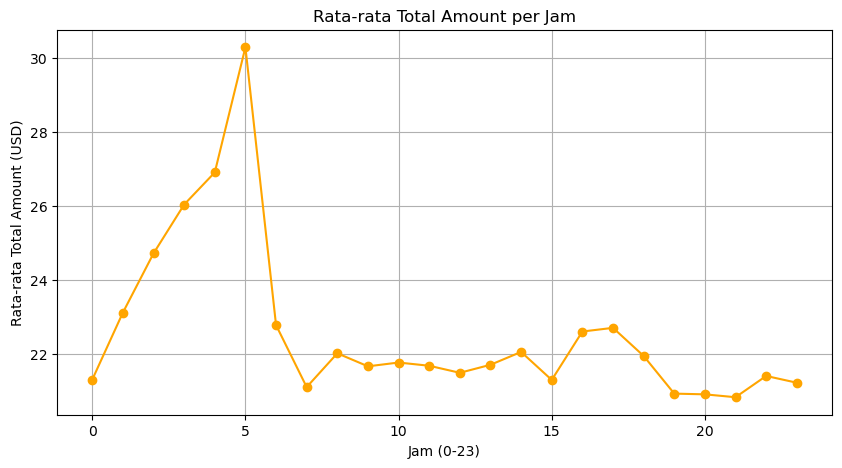

<Figure size 640x480 with 0 Axes>

In [43]:
# (6.2) Analisis rata-rata total_amount dengan rata- rata pickup hour 
# Didapatkan rata-rata total amount paling tinggi ada di menuju jam 05

df_cleaned['lpep_pickup_datetime'] = pd.to_datetime(df_cleaned['lpep_pickup_datetime'])

# Tambahkan kolom jam dan hari
df_cleaned['pickup_hour'] = df_cleaned['lpep_pickup_datetime'].dt.hour

# Rata-rata pickup hour
avg_pickup_hour = df_cleaned.groupby('pickup_hour')['total_amount'].mean()

plt.figure(figsize=(10,5))
avg_pickup_hour.plot(kind='line', marker='o', color='orange')
plt.title("Rata-rata Total Amount per Jam")
plt.xlabel("Jam (0-23)")
plt.ylabel("Rata-rata Total Amount (USD)")
plt.grid(True)
plt.show()
plt.savefig('Rata-rata Total Amount per Jam.png')   

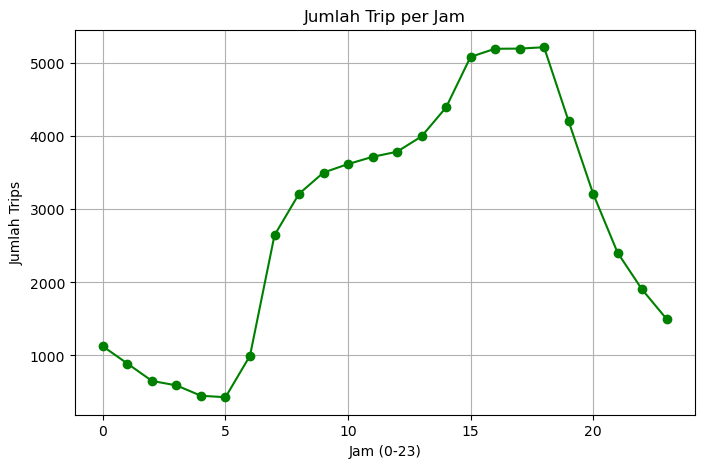

<Figure size 640x480 with 0 Axes>

In [42]:
# (6.3) Analisis jumlah trip dengan rata- rata pickup hour 
# Didapatkan jumlah trip per jam paling banyak ada di range jam 15 - 20 

df_cleaned['pickup_hour'] = df_cleaned['lpep_pickup_datetime'].dt.hour

# Tambahkan jumlah_trip_per_hour
jumlah_trip_per_hour = df_cleaned.groupby('pickup_hour').size()
plt.figure(figsize=(8,5))
jumlah_trip_per_hour.plot(kind='line', marker='o', color='green')
plt.title("Jumlah Trip per Jam")
plt.xlabel("Jam (0-23)")
plt.ylabel("Jumlah Trips")
plt.grid(True)
plt.show()
plt.savefig('Rata-rata Jumlah trip per Jam.png')

In [44]:
# (6.4) Top 10 pickup location
# Berdasarkan data pickup location didapatkan 10 lokasi dengan demand terbanyak sebagai berikut

top10_pickup = print(df_cleaned['PULocationID'].value_counts().head(10))

PULocationID
74     13243
75      9085
41      4044
166     3875
95      3830
82      2917
43      2863
97      2192
7       1955
244     1803
Name: count, dtype: int64


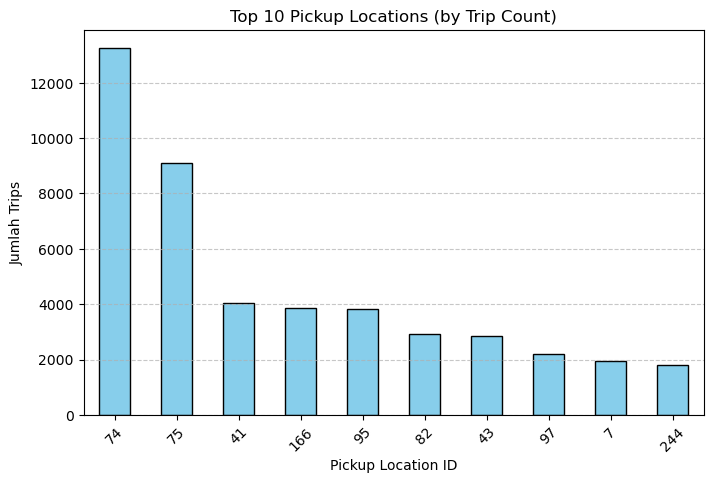

In [49]:
# Plot bar chart
plt.figure(figsize=(8,5))
top10_pickup.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Top 10 Pickup Locations (by Trip Count)")
plt.xlabel("Pickup Location ID")
plt.ylabel("Jumlah Trips")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [40]:
# Kesimpulan dan Rekomendasi

# 1. Berdasarkan analisis z-test, didapatkan p-value < 0,05 sehingga secara statistik jumlah trip = 0 sebesar 4.9% adalah signifikan. 
# --> Adanya monitoring kepada driver setiap bulan untuk mengurangi kejadian trip distance = 0, dikarenakan ada potensi fraud, pembatalan dan lain -lain
# --> hal ini penting untuk mendorong productivity driver

# 2. Ditemukan rata-rata total amount paling tinggi ada di menuju jam 05 pagi. Hal ini menunjukkan adanya kontribusi pemasukan yang besar pada jam tersebut 
# --> Walaupun jumlah tripnya sedikit, tapi kontribusi per trip tinggi 
# --> Sehingga perlu dijaga loyalitas customer yang sudah terbiasa memakai jasa kita 
# --> Pendataan customer pagi untuk diberikan treatment khusus seperti diskon dan layanan express karena biasanya dibutuhkan cepat

# 3. Analisis jumlah trip dengan rata- rata pickup hour menunjukkan demand paling banyak berada pada range jam 15 - 20 
# --> Demand yang tinggi pada jam tersebut dapat menghasilkan revenue yang besar juga
# --> Memastikan jumlah supply driver yang lebih banyak pada jam tersebut dengan membuat shift driver  

# 4. Top 10 pickup location ada di lokasi 74, 75, 41, 166, 95, 82, 43, 97, 7, dan 244
# --> Penempatan driver dapat diperbanyak pada area yang memiliki banyak demand seperti diatas